Importing the required libraries and modules

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tsa.arima.model import ARIMA

Loading the data

In [2]:
df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

In [3]:
df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722


In [4]:
df.shape

(2640, 12)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [5]:
df.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [8]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicates: 0


No null values neither duplicates

Combining the Year and Month columns to date column.
Droping the Year and Month columns.
Droping the Source_Type column

In [10]:
df["Date"] = pd.to_datetime(
    df["Year"].astype(str)+"-"+df["Month"].astype(str)+"-01"
)
df.drop(columns=["Year","Month","Source_Type"], inplace=True)

In [12]:
df.describe()
df.shape

(2640, 10)

Creating a copy of the DataFrame

In [13]:
df_ts = df.copy() #for TimeSeries Forecasting

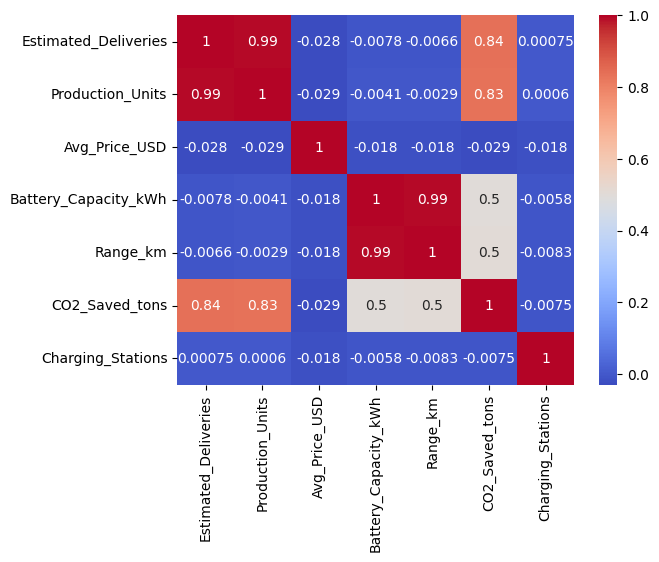

In [14]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()



*   Estimated_Deliveries and Production_units have strong positive correlation.
*   Estimated_Deliveries with CO2_Saved_Tons also have strong correlation.
*   Estimated_Deliveries and Charging_Stations have positive but weak correlation
*   Battery_Capacity_kWh and Range_km have strong correlation. (Can cause Multicollinearity)










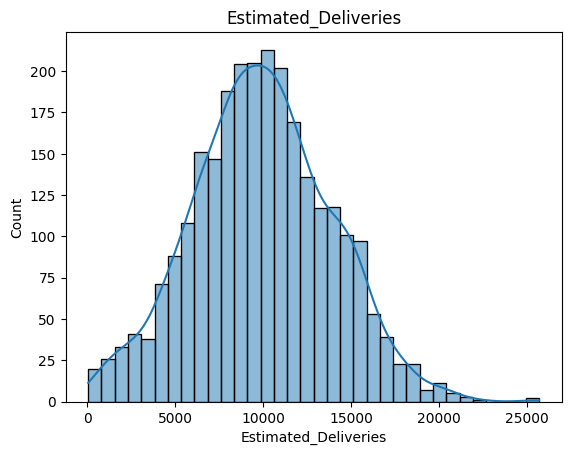

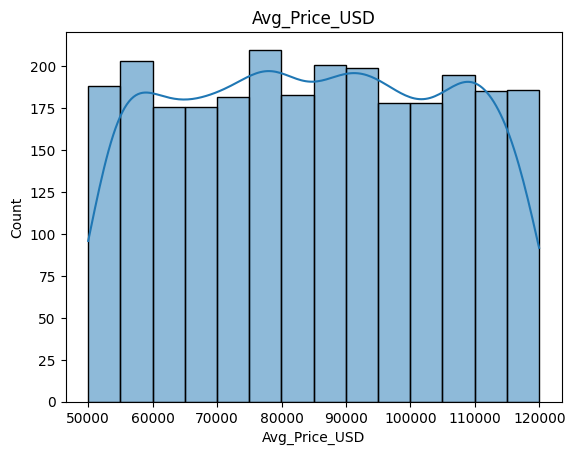

In [15]:
for c in ["Estimated_Deliveries","Avg_Price_USD"]:
    sns.histplot(df[c], kde=True)
    plt.title(c)
    plt.show()

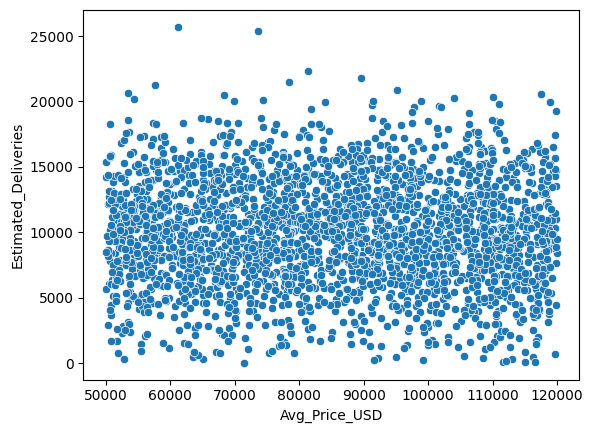

In [16]:
sns.scatterplot(data=df,x="Avg_Price_USD",y="Estimated_Deliveries")
plt.show()

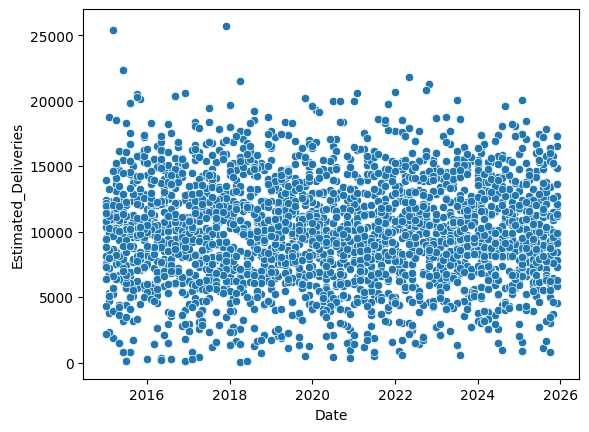

In [84]:
sns.scatterplot(data=df,x="Date",y="Estimated_Deliveries")
plt.show()

**Observation:**
Not a Time-Driven dataset

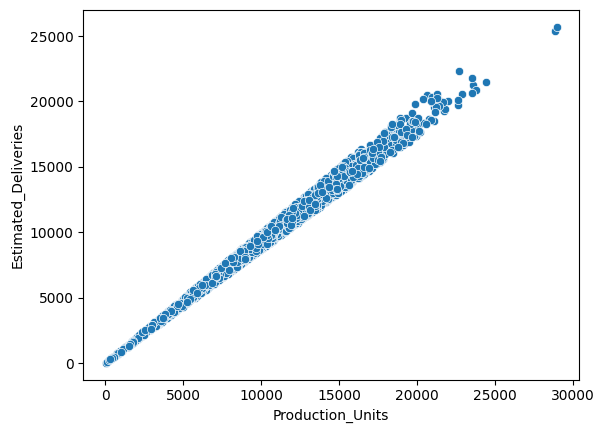

In [17]:
sns.scatterplot(data=df,x="Production_Units",y="Estimated_Deliveries")
plt.show()

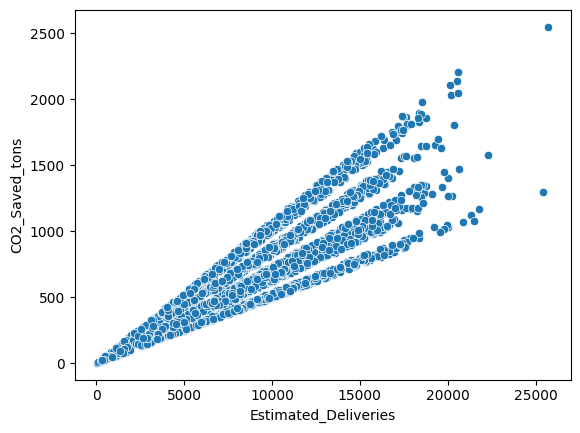

In [19]:
sns.scatterplot(data=df,x="Estimated_Deliveries",y="CO2_Saved_tons")
plt.show()

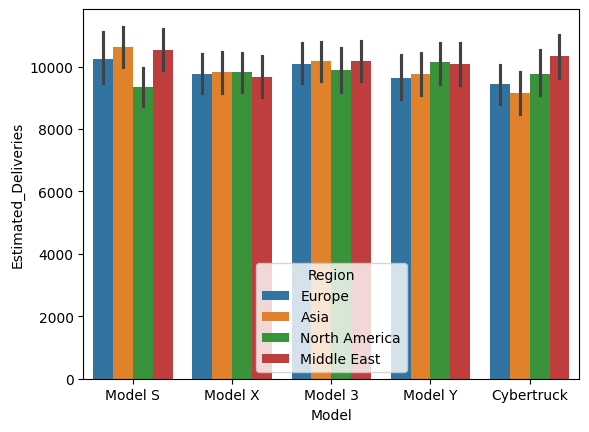

In [24]:
sns.barplot(x=df["Model"],y=df["Estimated_Deliveries"], hue=df["Region"])
plt.show()

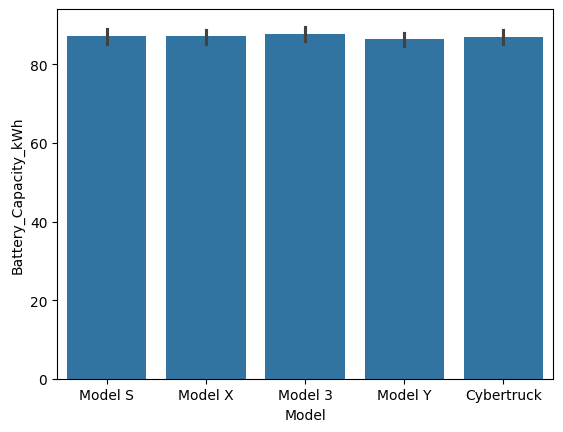

In [28]:
sns.barplot(x=df["Model"],y=df["Battery_Capacity_kWh"])
plt.show()

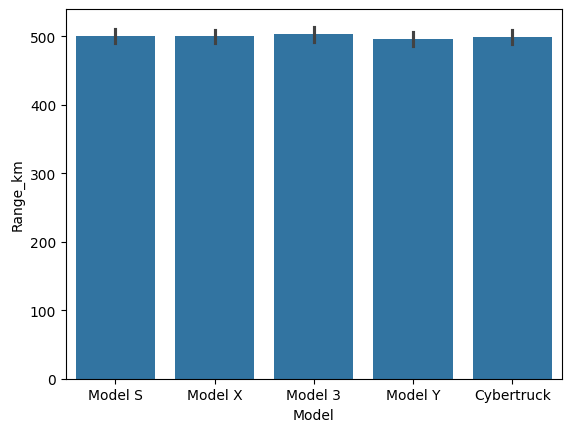

In [29]:
sns.barplot(x=df["Model"],y=df["Range_km"])
plt.show()

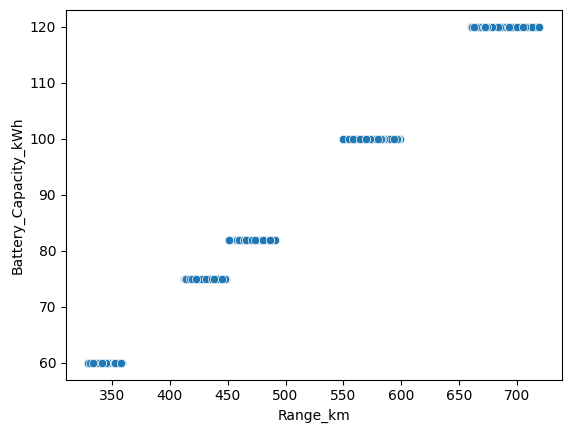

In [32]:
sns.scatterplot(data=df,x="Range_km",y="Battery_Capacity_kWh")
plt.show()

In [51]:
df_regres=df.copy() #Creating copy of the original dataset for regression models

In [53]:
df_regres.shape

(2640, 10)

Droping the "Battery_Capacity_kWh" column as it is highly correlated to the "Range_km" column and doesnot have much impact on the Target (Estimated_Deliveries)

In [54]:
df_regres.drop("Battery_Capacity_kWh", axis=1, inplace=True) # avoides multicollinearity

In [56]:
df_regres.shape

(2640, 9)

Converting the "Date" column values to numerical values for Regression model training

In [57]:
df_regres["Date"] = df_regres["Date"].map(pd.Timestamp.toordinal)

In [58]:
df_regres.head()

,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Range_km,CO2_Saved_tons,Charging_Stations,Date
0,Europe,Model S,17646,17922,92874.27,704,1863.42,12207,738641
1,Asia,Model X,3797,4164,62205.65,438,249.46,7640,735630
2,North America,Model X,8411,9189,117887.32,480,605.59,14071,737060
3,North America,Model 3,6555,7311,89294.91,712,700.07,9333,737822
4,Middle East,Model Y,12374,13537,114846.78,661,1226.88,8722,736299


In [59]:
X=df_regres.drop(columns=["Estimated_Deliveries"])
y=df_regres["Estimated_Deliveries"] #target value setting

In [60]:
cat=["Region","Model"]
num = [
    "Date",
    "Production_Units",
    "Avg_Price_USD",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

In [61]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42) #spiltting the dataset


*   Performing OneHot encoding (for the nominal categorical data i.e., Region and Model)
*   Scaling the numerical columns.



In [62]:
preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat),
        ("num", StandardScaler(), num)
    ]
)

In [63]:
models={
    "Linear":LinearRegression(),
    "Ridge":Ridge(),
    "Lasso":Lasso(max_iter=10000)
}

In [64]:
#Base Pipeline
for name,est in models.items():
    pipe=Pipeline([
        ("preprocessor",preprocessor),
        ("model",est)
    ])
    pipe.fit(X_train,y_train)
    pred=pipe.predict(X_test)
    print(name)
    print("MAE",mean_absolute_error(y_test,pred))
    print("RMSE",np.sqrt(mean_squared_error(y_test,pred)))
    print("R2",r2_score(y_test,pred))

Linear
MAE 309.37751439547424
RMSE 383.6815149952367
R2 0.9901242010333209
Ridge
MAE 309.23590399405526
RMSE 383.825975976517
R2 0.9901167629049089
Lasso
MAE 309.3036916485037
RMSE 383.0563718270169
R2 0.9901563566543219



**Observation:**
*   Linear Regression, Ridge, and Lasso performed almost identically, indicating that the dataset has strong linear relationships and low overfitting.
*   Regularization did not significantly improve performance, suggesting minimal multicollinearity impact after preprocessing.



In [65]:
ridge_pipe=Pipeline([
    ("preprocessor",preprocessor),
    ("model",Ridge())
])

In [66]:
ridge_grid=GridSearchCV(
    ridge_pipe,
    {"model__alpha":[0.01,0.1,1,10,100]},
    cv=5,
    scoring="r2")

In [70]:
ridge_grid.fit(X_train, y_train)
best_ridge = ridge_grid.best_estimator_

ridge_pred = best_ridge.predict(X_test)

print("Ridge after tuning")
print("MAE:", mean_absolute_error(y_test, ridge_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)))
print("R2:", r2_score(y_test, ridge_pred))
print("Best Ridge",ridge_grid.best_params_)

Ridge after tuning
MAE: 309.36316307155124
RMSE: 383.6943465863662
R2: 0.9901235404628818
Best Ridge {'model__alpha': 0.1}



**Observation:**
*   After hyperparameter tuning, Ridge regression with alpha=0.1 performed almost identically to Linear Regression, indicating minimal overfitting and well-conditioned feature space after preprocessing.
*   Regularization did not significantly improve generalization.



In [71]:
lasso_pipe=Pipeline([
    ("preprocessor",preprocessor),
    ("model",Lasso(max_iter=10000))
])

In [72]:
lasso_grid=GridSearchCV(
    lasso_pipe,
    {"model__alpha":[0.001,0.01,0.1,1,10]},
    cv=5,
    scoring="r2"
)

In [74]:
lasso_grid.fit(X_train,y_train)
best_lasso = lasso_grid.best_estimator_

lasso_pred = best_lasso.predict(X_test)

print("Lasso after tuning")
print("MAE:", mean_absolute_error(y_test, lasso_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)))
print("R2:", r2_score(y_test, lasso_pred))
print("Best Lasso",lasso_grid.best_params_)

Lasso after tuning
MAE: 309.3036916485037
RMSE: 383.0563718270169
R2: 0.9901563566543219
Best Lasso {'model__alpha': 1}


**Observation:**


*   Lasso did not significantly reduce the number of features, suggesting that most input features contribute meaningfully to predicting the target variable.
*   Therefore, feature selection through Lasso regularization was not highly impactful in this dataset.



**TimeSeries**

In [76]:
#Preparing for Time Series Forecasting
ts=(df_ts.groupby("Date")["Estimated_Deliveries"].sum().sort_index())
train=ts.iloc[:-12]
test=ts.iloc[-12:]

Training ARIMA model

In [77]:
model=ARIMA(train,order=(1,1,1))
fit=model.fit()
forecast=fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


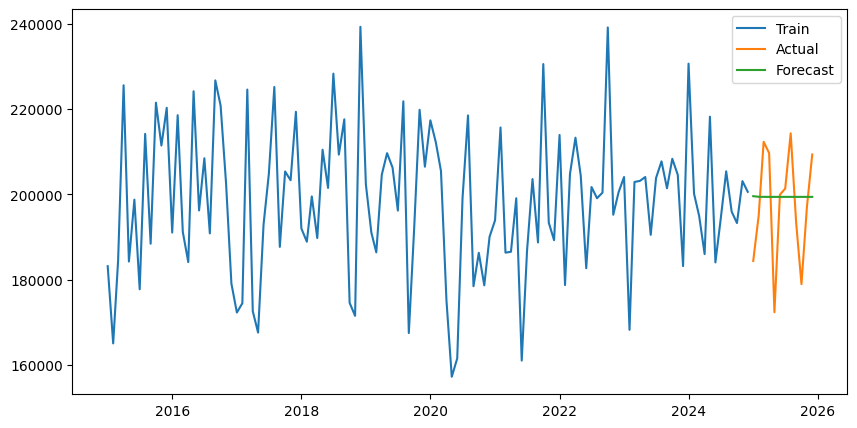

In [78]:
plt.figure(figsize=(10,5))
plt.plot(train.index,train,label="Train")
plt.plot(test.index,test,label="Actual")
plt.plot(test.index,forecast,label="Forecast")
plt.legend()
plt.show()

In [79]:
print("ARIMA Model Evaluation:")
print("MAE:", mean_absolute_error(test, forecast))
print("RMSE:", np.sqrt(mean_squared_error(test, forecast)))
print("R2:", r2_score(test, forecast))

ARIMA Model Evaluation:
MAE: 10504.31381301446
RMSE: 13046.159988784257
R2: -0.028366666528699458


Training SARIMA Model

In [80]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(
    train,
    order=(1,1,1),
    seasonal_order=(1,1,1,12)   # 12 = yearly seasonality for monthly data
)

fit = model.fit()

forecast = fit.forecast(steps=len(test))

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


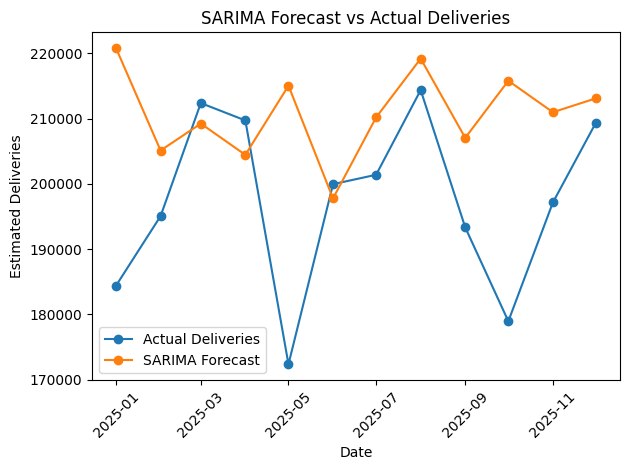

In [81]:
plt.plot(test.index, test, label="Actual Deliveries", marker='o')
plt.plot(test.index, forecast, label="SARIMA Forecast", marker='o')

plt.title("SARIMA Forecast vs Actual Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [83]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
r2 = r2_score(test, forecast)

print("MAE: ",mae)
print("RMSE: ",rmse)
print("R2: ",r2)

MAE:  15109.869133982696
RMSE:  20683.908669059707
R2:  -1.584924207587926




*   No seasonality in the data
*   Dataset is feature driven and not time-driven

